In [3]:
import torch
print(torch.__version__)
print("torch available",torch.cuda.is_available())

2.10.0+cu128
torch available True


In [4]:
import torchvision
import torchvision.transforms as transforms

# Transform images to tensors and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download and load training data
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)

# Download and load test data
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)

print("Training images:", len(trainset))
print("Test images:", len(testset))

100%|██████████| 170M/170M [00:05<00:00, 30.5MB/s]


Training images: 50000
Test images: 10000


In [5]:
from torch.utils.data import DataLoader

trainloader=DataLoader(trainset,batch_size=32,shuffle=True)
testloader=DataLoader(testset,batch_size=32,shuffle=True)

print("Number of training batches:",len(trainloader))
print("Number of test batches:", len(testloader))

Number of training batches: 1563
Number of test batches: 313


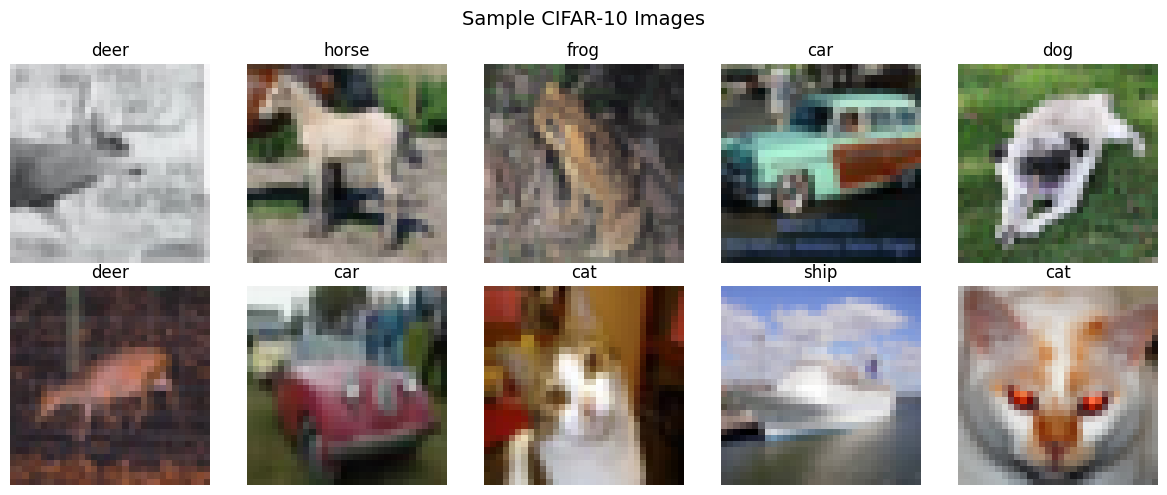

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Class names
classes = ['airplane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Get one batch of images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Plot 10 images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    img = images[i]
    img = img / 2 + 0.5  # unnormalize back to 0-1
    img = img.numpy().transpose((1, 2, 0))  # convert to HWC format for matplotlib
    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')

plt.suptitle('Sample CIFAR-10 Images', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        # Conv layer 1
        x = self.pool(F.relu(self.conv1(x)))
        # Conv layer 2
        x = self.pool(F.relu(self.conv2(x)))
        # Flatten
        x = x.view(-1, 64 * 8 * 8)
        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN()
print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


In [8]:
import torch.optim as optim

#Move model to GPU
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)

#Loss function
criterion=nn.CrossEntropyLoss()

#Optimizer
optimizer=optim.Adam(model.parameters(),lr=0.001)
print("Training On:", device)
print("Model Ready!")

Training On: cuda
Model Ready!


In [9]:
num_epochs = 10
for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in trainloader:
        # Move data to GPU
        images, labels = images.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Track accuracy
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(trainloader):.3f} - Accuracy: {accuracy:.2f}%")

print("Training Complete!")

Epoch 1/10 - Loss: 1.268 - Accuracy: 54.34%
Epoch 2/10 - Loss: 0.875 - Accuracy: 69.00%
Epoch 3/10 - Loss: 0.687 - Accuracy: 75.84%
Epoch 4/10 - Loss: 0.522 - Accuracy: 81.49%
Epoch 5/10 - Loss: 0.372 - Accuracy: 87.08%
Epoch 6/10 - Loss: 0.252 - Accuracy: 91.34%
Epoch 7/10 - Loss: 0.164 - Accuracy: 94.25%
Epoch 8/10 - Loss: 0.123 - Accuracy: 95.79%
Epoch 9/10 - Loss: 0.097 - Accuracy: 96.67%
Epoch 10/10 - Loss: 0.083 - Accuracy: 97.12%
Training Complete!


In [10]:
correct = 0
total = 0

model.eval()  # switch to evaluation mode

with torch.no_grad():  # don't calculate gradients
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 70.81%


In [11]:
import torchvision.models as models

# Load pretrained ResNet50
resnet = models.resnet50(pretrained=True)

# Freeze all layers - don't touch the existing knowledge!
for param in resnet.parameters():
    param.requires_grad = False

# Replace final layer with our 10 class version
import torch.nn as nn
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

# Move to GPU
resnet = resnet.to(device)

print(resnet.fc)
print("Model ready!")

Linear(in_features=2048, out_features=10, bias=True)
Model ready!


In [12]:
# Only train the final layer
optimizer_resnet = optim.Adam(resnet.fc.parameters(), lr=0.001)
criterion_resnet = nn.CrossEntropyLoss()

print("Training setup Complete!")
print(f"Trainable parameters: {sum(p.numel() for p in resnet.fc.parameters())}")
print(f"Frozen parameters: {sum(p.numel() for p in resnet.parameters()) - sum(p.numel() for p in resnet.fc.parameters())}")

Training setup Complete!
Trainable parameters: 20490
Frozen parameters: 23508032


In [13]:
num_epochs = 5
for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    resnet.train()
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer_resnet.zero_grad()
        outputs = resnet(images)
        loss = criterion_resnet(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/5 - Loss: {running_loss/len(trainloader):.3f} - Accuracy: {accuracy:.2f}%")

print("Training Complete!")

Epoch 1/5 - Loss: 1.692 - Accuracy: 42.29%
Epoch 2/5 - Loss: 1.562 - Accuracy: 47.21%
Epoch 3/5 - Loss: 1.532 - Accuracy: 48.09%
Epoch 4/5 - Loss: 1.510 - Accuracy: 48.74%
Epoch 5/5 - Loss: 1.501 - Accuracy: 49.27%
Training Complete!


In [14]:
# New transform with resize for ResNet50
transform_resnet = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Reload dataset with new transform
trainset_resnet = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=False, transform=transform_resnet)
testset_resnet = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=False, transform=transform_resnet)

# New dataloaders
trainloader_resnet = DataLoader(trainset_resnet, batch_size=32, shuffle=True)
testloader_resnet = DataLoader(testset_resnet, batch_size=32, shuffle=False)

print("Data reloaded with 224x224 resize!")

Data reloaded with 224x224 resize!


In [15]:
# Reload fresh ResNet50
resnet = models.resnet50(pretrained=True)

# Freeze all layers
for param in resnet.parameters():
    param.requires_grad = False

# Replace final layer
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

# Move to GPU
resnet = resnet.to(device)

# Setup optimizer
optimizer_resnet = optim.Adam(resnet.fc.parameters(), lr=0.001)
criterion_resnet = nn.CrossEntropyLoss()

print("ResNet50 ready!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet50 ready!


In [16]:
num_epochs = 5
for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    resnet.train()
    for images, labels in trainloader_resnet:
        images, labels = images.to(device), labels.to(device)

        optimizer_resnet.zero_grad()
        outputs = resnet(images)
        loss = criterion_resnet(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/5 - Loss: {running_loss/len(trainloader_resnet):.3f} - Accuracy: {accuracy:.2f}%")

print("Training Complete!")

Epoch 1/5 - Loss: 0.759 - Accuracy: 74.31%
Epoch 2/5 - Loss: 0.628 - Accuracy: 78.41%
Epoch 3/5 - Loss: 0.610 - Accuracy: 79.04%
Epoch 4/5 - Loss: 0.581 - Accuracy: 79.87%
Epoch 5/5 - Loss: 0.567 - Accuracy: 80.66%
Training Complete!


In [17]:
num_epochs = 5
for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    resnet.train()
    for images, labels in trainloader_resnet:
        images, labels = images.to(device), labels.to(device)

        optimizer_resnet.zero_grad()
        outputs = resnet(images)
        loss = criterion_resnet(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+6}/10 - Loss: {running_loss/len(trainloader_resnet):.3f} - Accuracy: {accuracy:.2f}%")

print("Training Complete!")

Epoch 6/10 - Loss: 0.557 - Accuracy: 81.00%
Epoch 7/10 - Loss: 0.549 - Accuracy: 81.13%
Epoch 8/10 - Loss: 0.539 - Accuracy: 81.33%
Epoch 9/10 - Loss: 0.529 - Accuracy: 81.84%
Epoch 10/10 - Loss: 0.526 - Accuracy: 81.70%
Training Complete!


In [18]:
# Unfreeze the last block of ResNet (layer4)
for param in resnet.layer4.parameters():
    param.requires_grad = True

# New optimizer - include layer4 parameters
optimizer_resnet = optim.Adam([
    {'params': resnet.layer4.parameters(), 'lr': 0.0001},  # small lr for layer4
    {'params': resnet.fc.parameters(), 'lr': 0.001}         # normal lr for fc
])

print("Unfrozen layer4!")
print(f"Trainable parameters: {sum(p.numel() for p in resnet.parameters() if p.requires_grad)}")

Unfrozen layer4!
Trainable parameters: 14985226


In [19]:
num_epochs = 5
for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    resnet.train()
    for images, labels in trainloader_resnet:
        images, labels = images.to(device), labels.to(device)

        optimizer_resnet.zero_grad()
        outputs = resnet(images)
        loss = criterion_resnet(outputs, labels)
        loss.backward()
        optimizer_resnet.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/5 - Loss: {running_loss/len(trainloader_resnet):.3f} - Accuracy: {accuracy:.2f}%")

print("Fine Tuning Complete!")

Epoch 1/5 - Loss: 0.445 - Accuracy: 85.55%
Epoch 2/5 - Loss: 0.200 - Accuracy: 93.10%
Epoch 3/5 - Loss: 0.126 - Accuracy: 95.70%
Epoch 4/5 - Loss: 0.092 - Accuracy: 96.87%
Epoch 5/5 - Loss: 0.071 - Accuracy: 97.60%
Fine Tuning Complete!


In [20]:
correct = 0
total = 0

resnet.eval()

with torch.no_grad():
    for images, labels in testloader_resnet:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 90.94%
